Optimal logistic regression loss L* = 0.3496535537094631


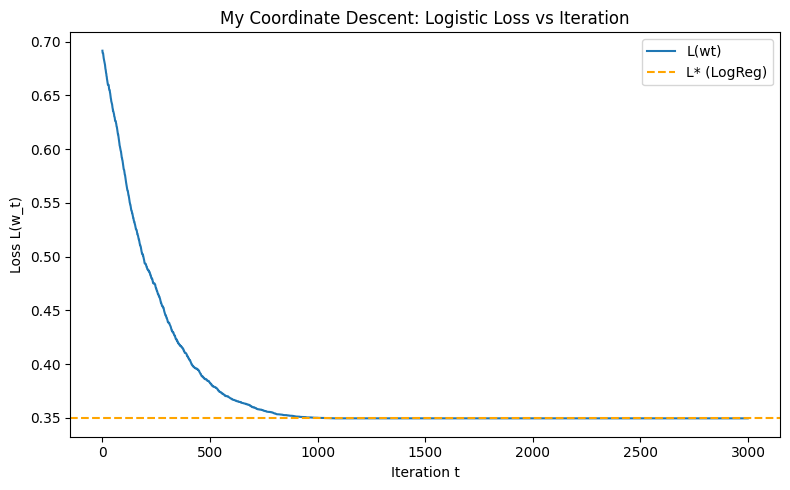

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression


def logistic_loss(w, X, y):
    z = X @ w
    p = 1 / (1 + np.exp(-z))
    return log_loss(y, p, labels=[0,1])


def coordinate_descent_random(
    X, y,
    steps=3000,
    step_size=0.01
):
    N, d = X.shape
    w = np.zeros(d)
    losses = []

    for t in range(steps):
        i = np.random.randint(0, d)

        L_now = logistic_loss(w, X, y)

        # Try +eta
        w_plus = w.copy()
        w_plus[i] += step_size
        L_plus = logistic_loss(w_plus, X, y)

        # Try -eta
        w_minus = w.copy()
        w_minus[i] -= step_size
        L_minus = logistic_loss(w_minus, X, y)

        # Choose best direction
        if L_plus < L_now and L_plus <= L_minus:
            w = w_plus
            L_now = L_plus
        elif L_minus < L_now:
            w = w_minus
            L_now = L_minus

        losses.append(L_now)

    return w, losses

df = pd.read_csv("heart.csv")
X = df.drop("target", axis=1).values
y = df["target"].values

# Standardize features
X = (X - X.mean(axis=0)) / X.std(axis=0)

clf = LogisticRegression(C=1e10, max_iter=10000)
clf.fit(X, y)

z_star = X @ clf.coef_.ravel()
p_star = 1 / (1 + np.exp(-z_star))
L_star = log_loss(y, p_star, labels=[0,1])

print("Optimal logistic regression loss L* =", L_star)

w_final, loss_history = coordinate_descent_random(X, y)

plt.figure(figsize=(8,5))
plt.plot(loss_history, label="L(wt)")
plt.axhline(L_star, color="orange", linestyle="--", label="L* (LogReg)")
plt.xlabel("Iteration t")
plt.ylabel("Loss L(w_t)")
plt.title("My Coordinate Descent: Logistic Loss vs Iteration")
plt.legend()
plt.tight_layout()
plt.show()
